In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch 
import torch.nn as nn 
import torch.optim as optim 

In [ ]:
from pathlib import Path 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_regression


In [3]:
session_test_path = "/Users/thomasbush/Downloads/shared WithTWB/m001_s001_cricket.xlsx"

In [6]:
data = pd.read_excel(session_test_path)

## Data Exploratory Analysis 

<Axes: >

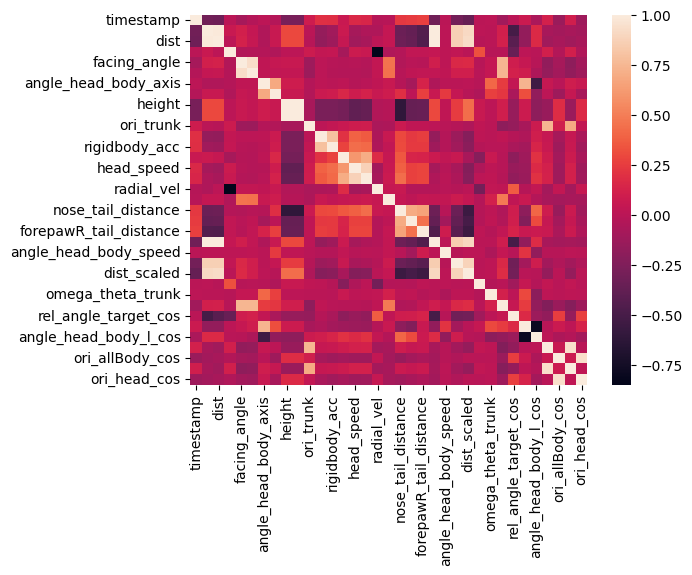

In [65]:
# Apply sin and cos transforms to angle features
angle_cols = [
    'acing_angle',
    'rel_angle_target',
    'angle_head_body_l',
    'ori_allBody',
    'ori_head'
]
for angle_col in angle_cols:
    if angle_col in data.columns:
        # Assuming angles are in degrees; convert to radians
        radians = np.deg2rad(data[angle_col])
        data[f'{angle_col}_sin'] = np.sin(radians)
        data[f'{angle_col}_cos'] = np.cos(radians)

# Create new DataFrame without the original angle columns, keeping only the sin/cos features and other columns
cols_to_keep = [col for col in data.columns if col not in angle_cols]
data_no_angle = data[cols_to_keep]

# Compute and plot correlation heatmap
sns.heatmap(data_no_angle.corr())



In [27]:
def check_distribution_and_outliers(
    df: pd.DataFrame, 
    plot: bool = True, 
    threshold: float = 3.5
) -> pd.DataFrame:
    """
    Analyze each numeric column in df to assess:
    - distribution tails (skewness, kurtosis)
    - presence of outliers (using robust Z-score based on median and IQR)
    - suitability for log1p transformation (positivity and skew)
    
    Args:
        df (pd.DataFrame): Input dataframe.
        plot (bool): If True, plots histograms/boxplots for each numeric feature.
        threshold (float): Threshold for robust Z-score to detect outliers.

    Returns:
        pd.DataFrame: Summary with statistics, log1p suggestion, and outlier counts.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    summary = []
    num_cols = df.select_dtypes(include=[np.number]).columns

    for col in num_cols:
        x = df[col].dropna()

        # Robust Z-score
        median = np.median(x)
        IQR = np.subtract(*np.percentile(x, [75, 25]))
        robust_z = 0.6745 * (x - median) / IQR if IQR > 0 else np.zeros_like(x)
        outliers = np.abs(robust_z) > threshold

        # Skew and kurtosis
        skew = x.skew()
        kurt = x.kurtosis()

        # Log1p transform suitability: all values >= 0 and highly skewed
        ok_for_log = (x.min() >= 0)
        suggest_log1p = ok_for_log and abs(skew) > 1

        summary.append({
            "feature": col,
            "skew": skew,
            "kurtosis": kurt,
            "suggest_log1p": suggest_log1p,
            "n_outliers": outliers.sum(),
            "outlier_pct": 100 * outliers.sum() / len(x) if len(x) > 0 else 0,
            "median": median,
            "IQR": IQR
        })

        if plot:
            fig, axes = plt.subplots(1, 2, figsize=(9, 3))
            x.hist(bins=50, ax=axes[0])
            axes[0].set_title(f"{col} - Histogram")
            axes[0].axvline(median, color='r', linestyle='--', label='Median')
            axes[0].legend()
            axes[1].boxplot(x, vert=False, notch=True)
            axes[1].set_title(f"{col} - Boxplot")
            plt.tight_layout()
            plt.show()

    return pd.DataFrame(summary)

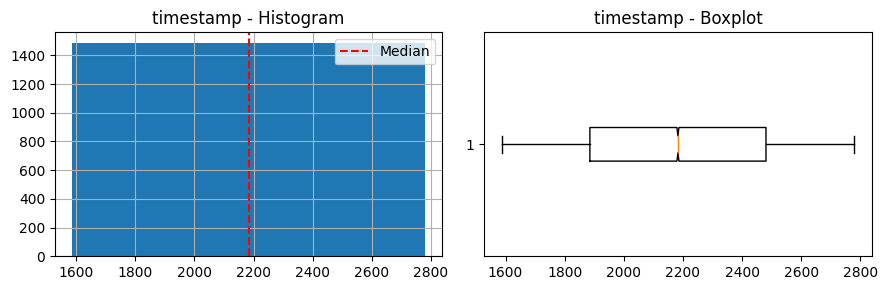

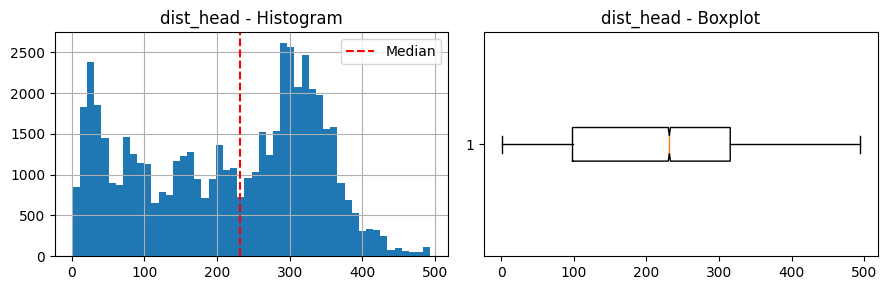

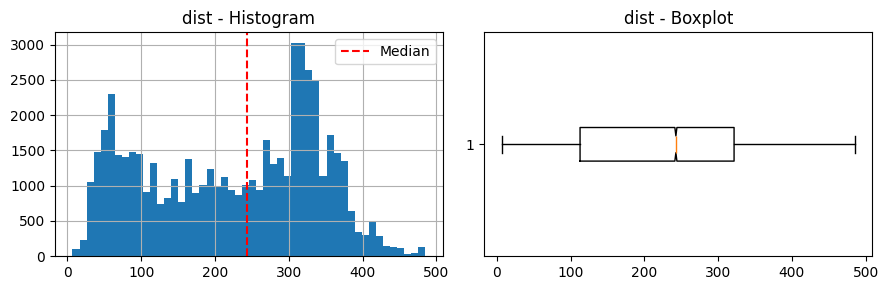

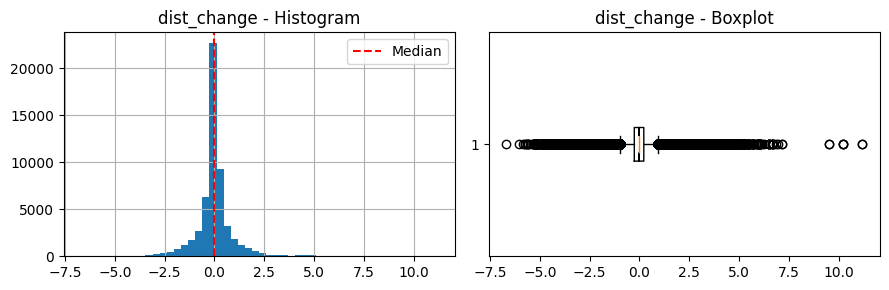

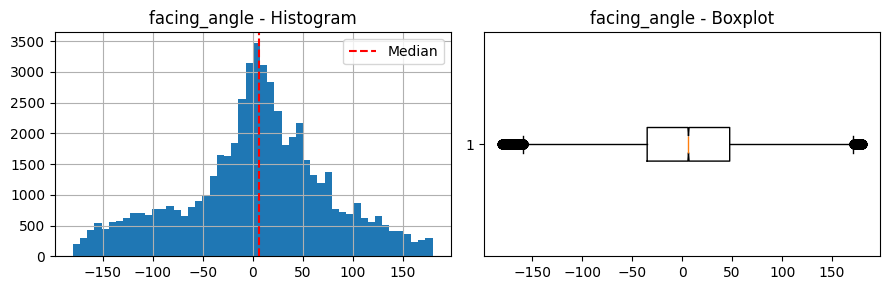

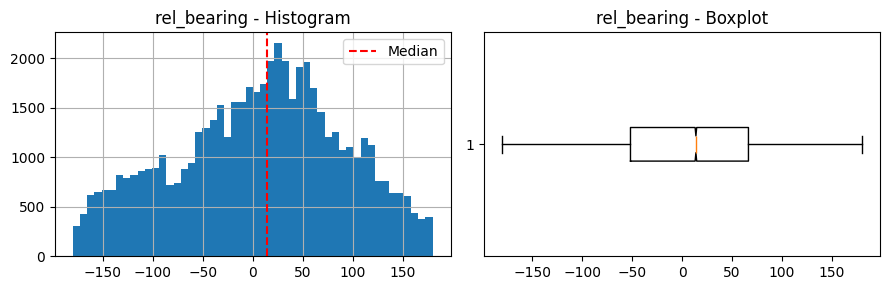

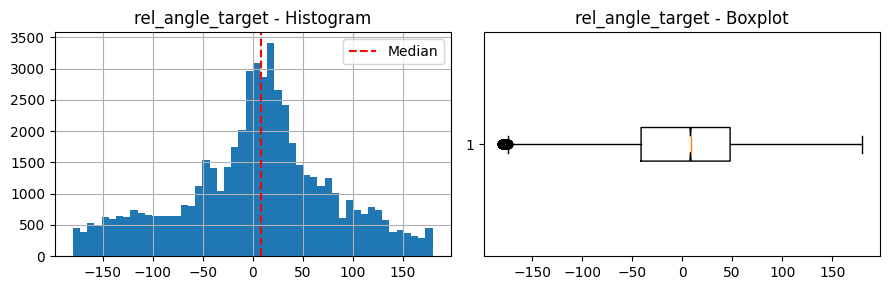

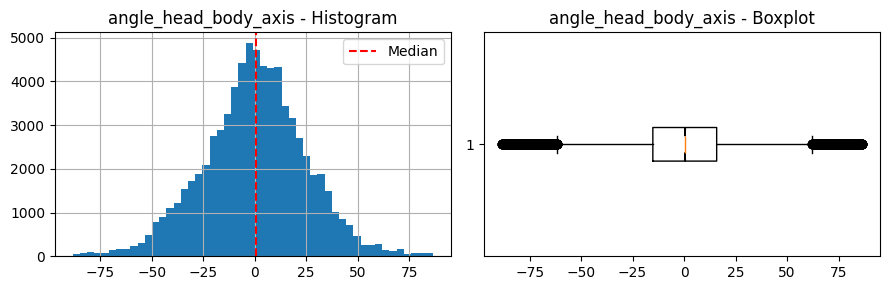

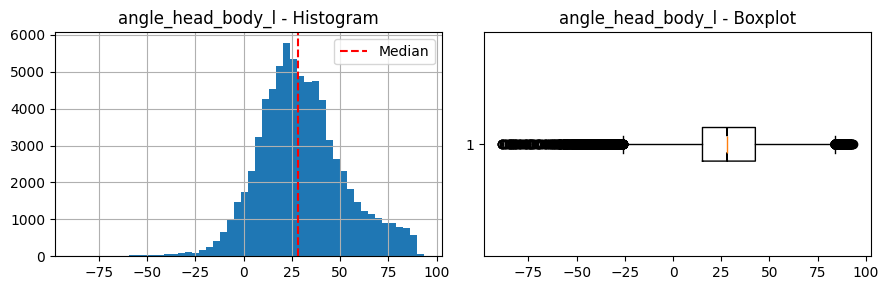

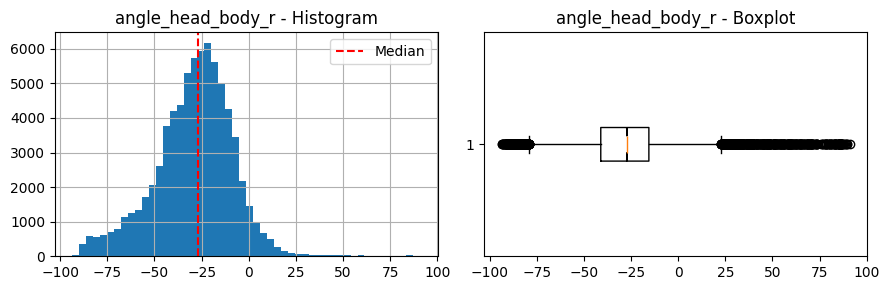

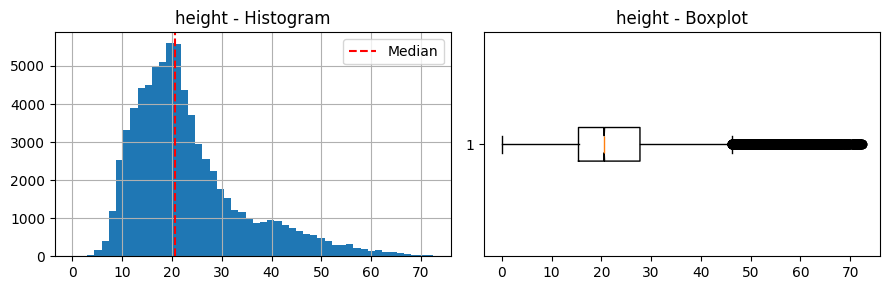

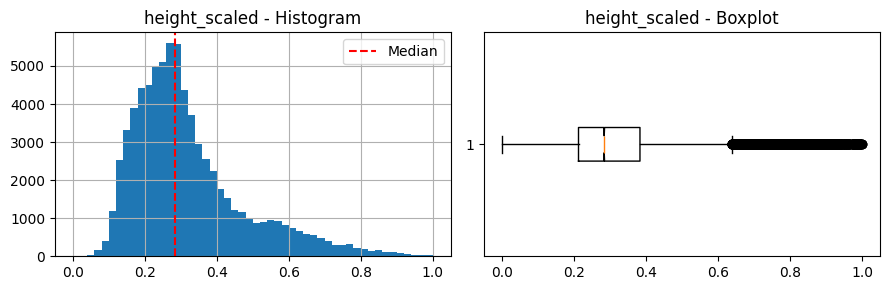

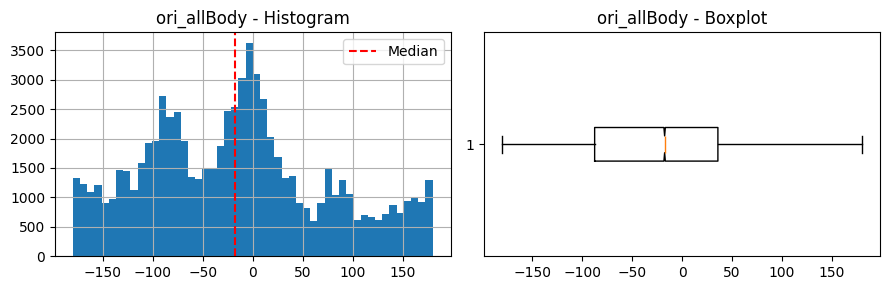

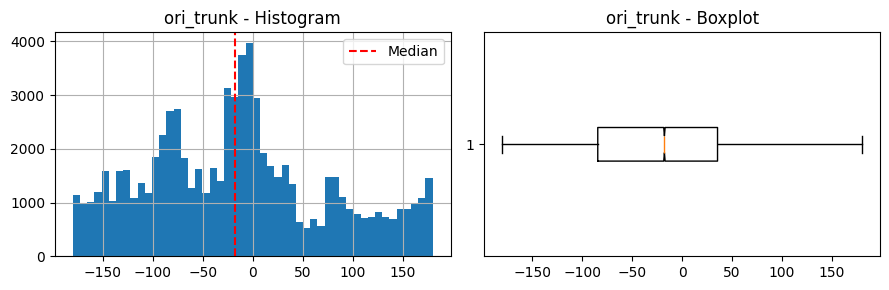

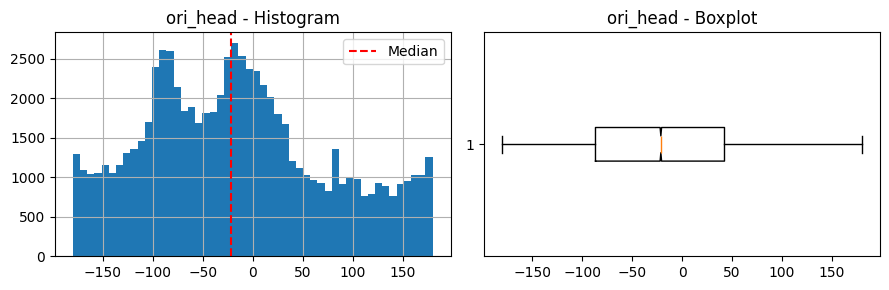

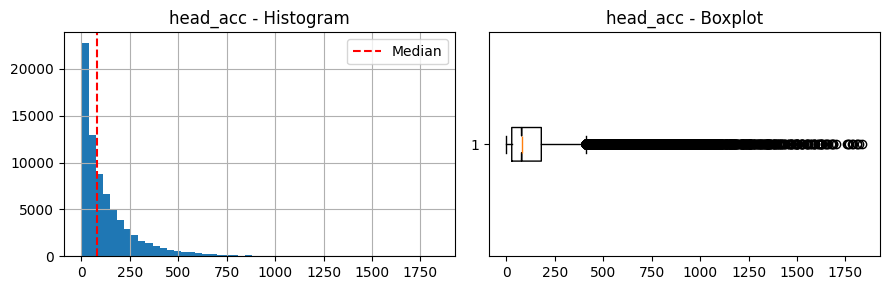

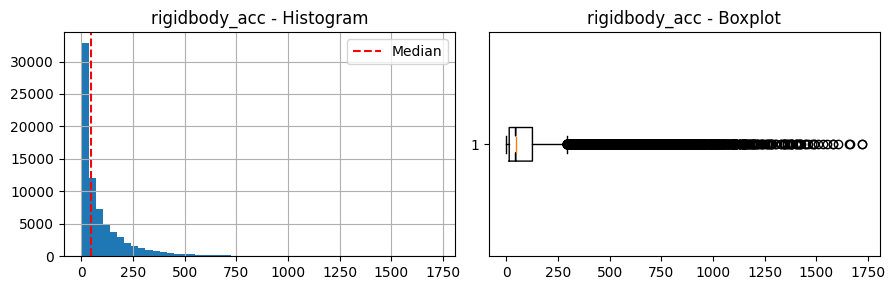

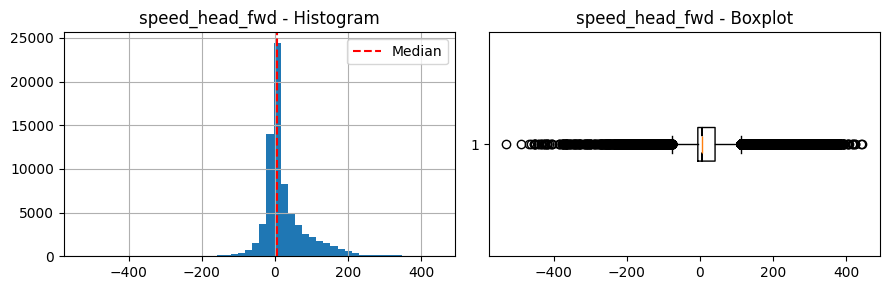

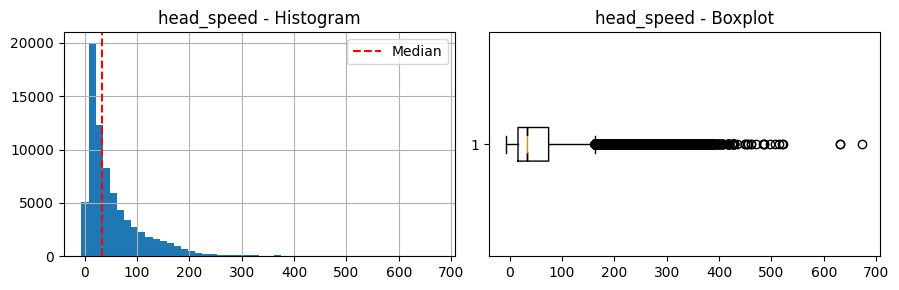

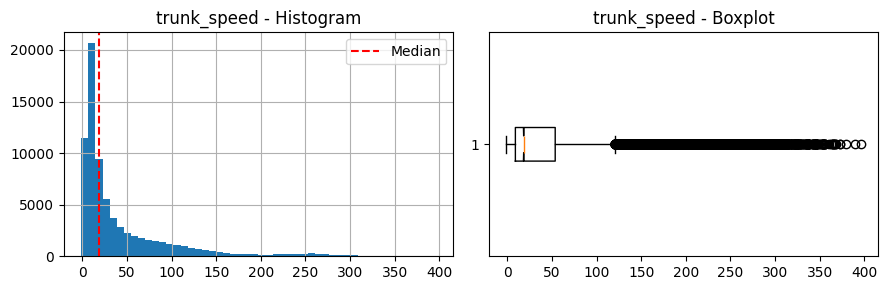

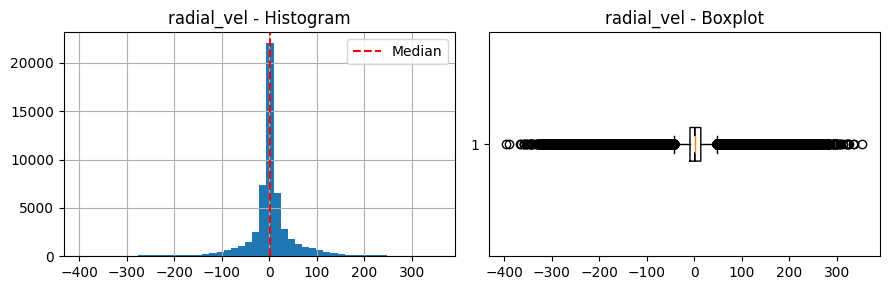

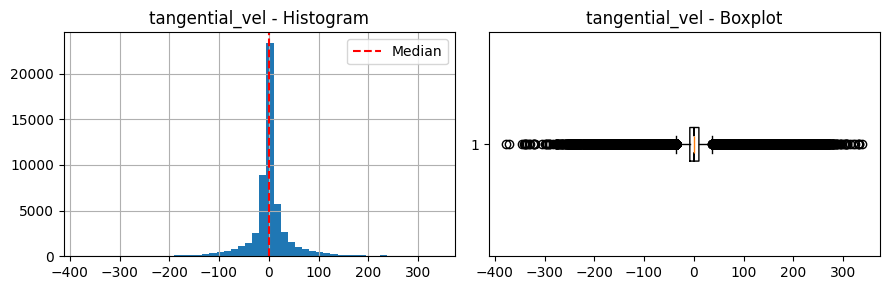

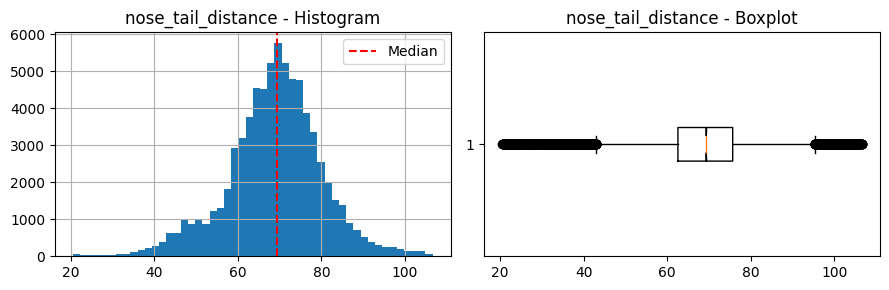

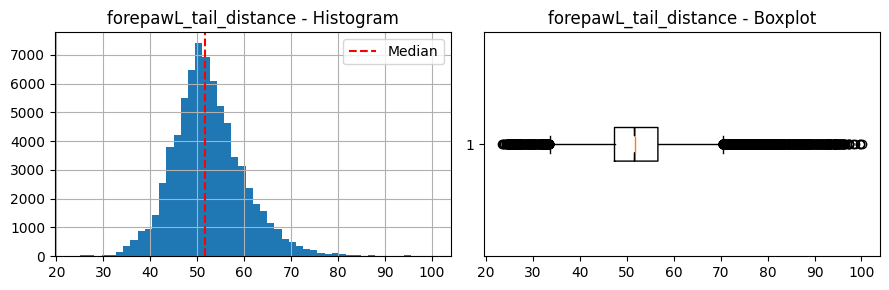

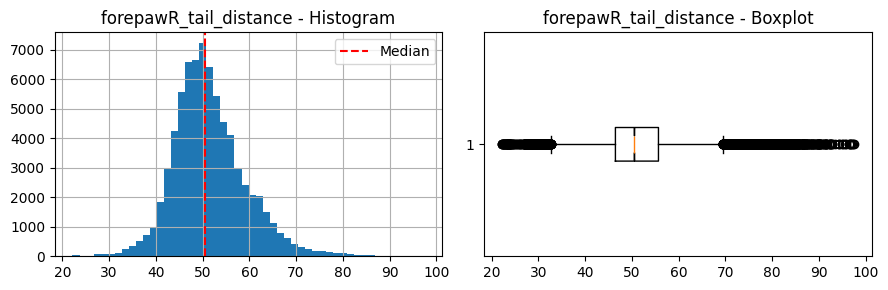

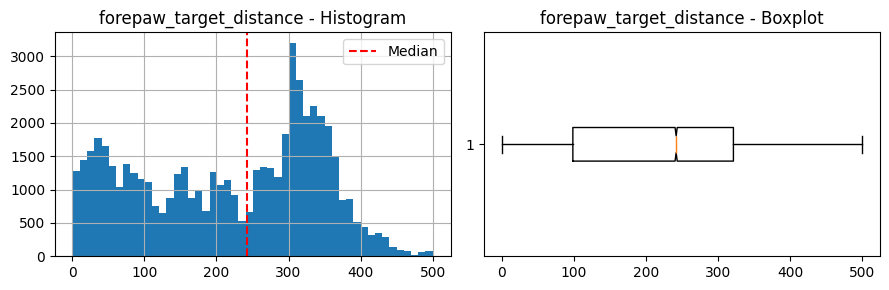

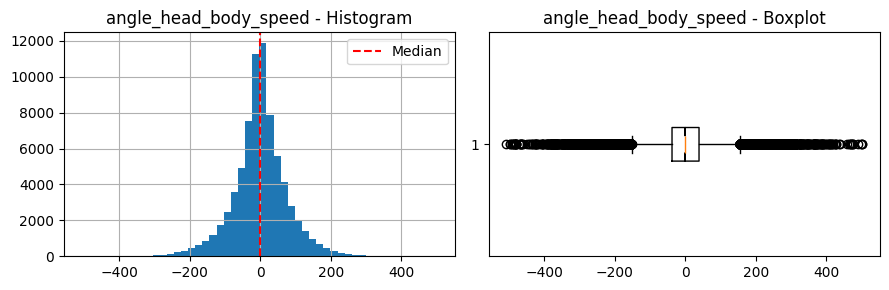

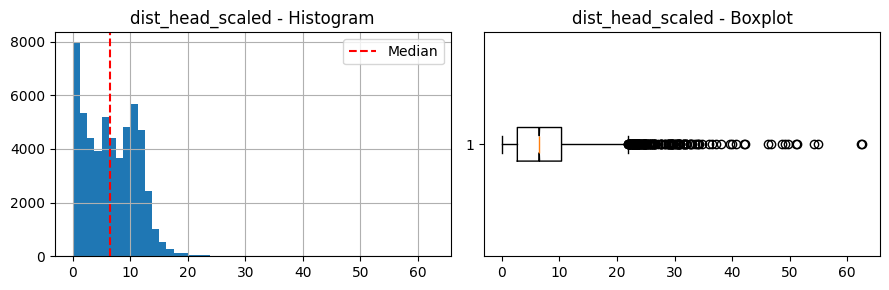

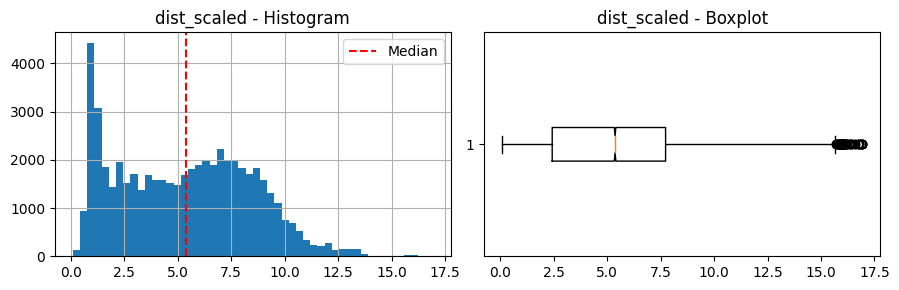

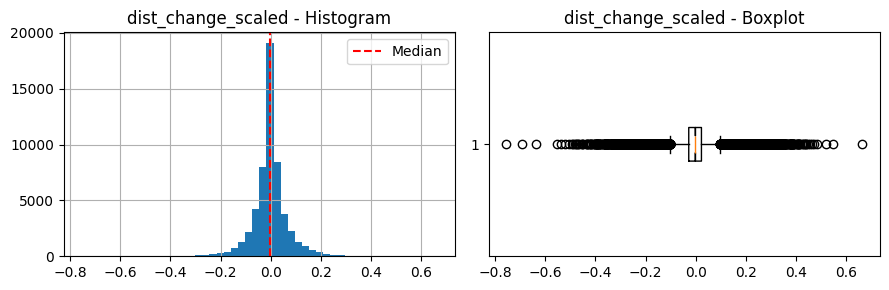

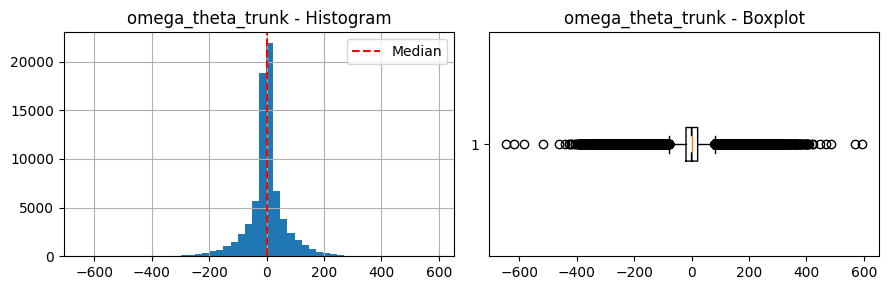

,feature,skew,kurtosis,suggest_log1p,n_outliers,outlier_pct,median,IQR
0,timestamp,-6.605267e-07,-1.200000,False,0,0.000000,2182.965750,595.518900
1,dist_head,-1.861006e-01,-1.218817,False,0,0.000000,231.654786,217.145798
2,dist,-1.673978e-01,-1.253492,False,0,0.000000,242.704506,208.812167
3,dist_change,7.026868e-01,9.492471,False,1852,3.378021,-0.010741,0.477459
4,facing_angle,-1.900518e-01,-0.070225,False,0,0.000000,6.335141,82.544118
5,rel_bearing,-1.867068e-01,-0.693482,False,0,0.000000,13.800485,118.027883
6,rel_angle_target,-1.991098e-01,-0.148204,False,0,0.000000,8.379591,89.021401
7,angle_head_body_axis,-7.387671e-02,0.446160,False,0,0.000000,0.491205,30.989422
8,angle_head_body_l,1.477329e-01,0.751260,False,0,0.000000,28.028972,27.416605
9,angle_head_body_r,-1.342686e-01,1.389878,False,0,0.000000,-27.168600,25.499291


In [28]:
check_distribution_and_outliers(data)

We check the distibution over time per for each feature:

In [41]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 18.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


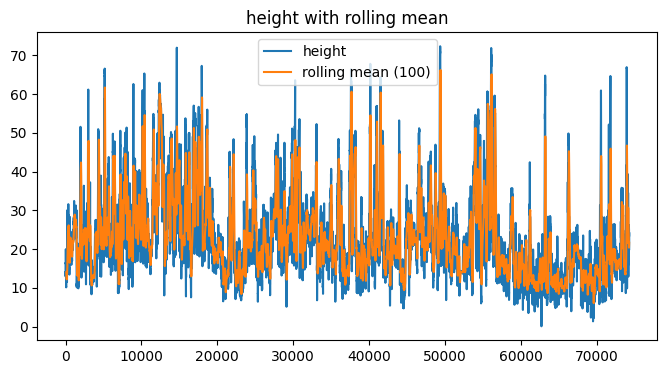

In [40]:
def plot_rolling_mean(df, column, window=60, ax=None):
    """
    Plots the original series and its rolling mean for a specified column in a DataFrame.

    Args:
        df (pd.DataFrame): The input data frame.
        column (str): Column name to plot.
        window (int): Rolling window size.
        ax (matplotlib.axes.Axes, optional): Axis to plot on.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    df[column].plot(ax=ax, title=f'{column} with rolling mean')
    df[column].rolling(window=window).mean().plot(ax=ax, label=f'rolling mean ({window})')
    ax.legend()
    plt.show()

# Example usage:
plot_rolling_mean(data, "height", window=100)

In [46]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import pandas as pd
import numpy as np

def plot_acf_for_column(df: pd.DataFrame, column: str, lags: int = 40, show_values: bool = True):
    """
    Plots the autocorrelation function (ACF) for a specified column in a pandas DataFrame.
    Optionally prints the autocorrelation values. The input series is normalized (zero mean, unit variance) before autocorrelation.

    Args:
        df (pd.DataFrame): Input DataFrame.
        column (str): Column name for which to plot ACF.
        lags (int): Number of lags to plot/check.
        show_values (bool): Whether to print the autocorrelation values.
    """
    series = df[column].dropna()
    # Normalize the series (zero mean, unit variance)
    normalized_series = (series - series.mean()) / series.std(ddof=0)
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_acf(normalized_series, lags=lags, ax=ax)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'Autocorrelation Plot for {column} (normalized)')
    plt.show()
    autocorr_values = acf(normalized_series, nlags=lags)
    if show_values:
        print(f"Autocorrelation values for '{column}' (normalized):", autocorr_values)
    return autocorr_values

# Example usage:
# plot_acf_for_column(data, 'height', lags=24)


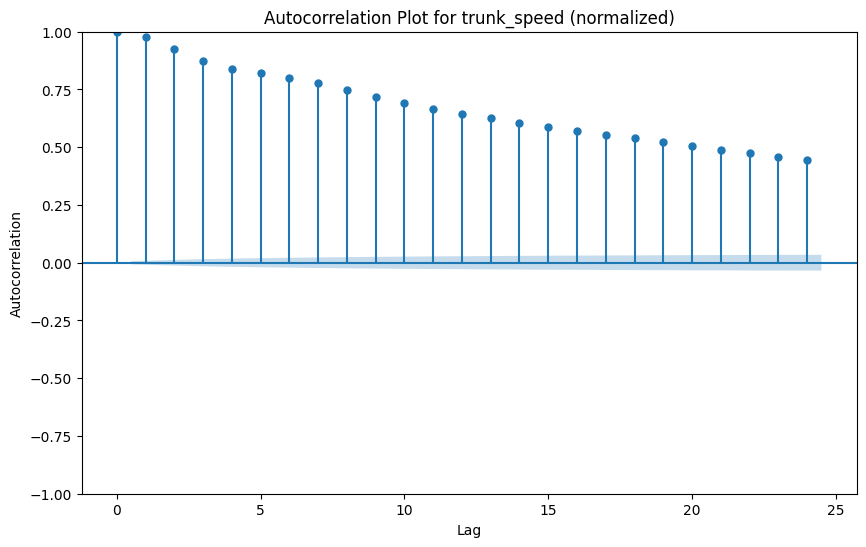

Autocorrelation values for 'trunk_speed' (normalized): [1.         0.97755686 0.9263824  0.87441756 0.83931276 0.81947497
 0.80169694 0.77671773 0.74687598 0.71734807 0.69086383 0.66707592
 0.64495857 0.62458107 0.60550472 0.58753343 0.57054218 0.5542137
 0.53799462 0.52151953 0.5049616  0.48880238 0.4733917  0.45860191
 0.44410698]


array([1.        , 0.97755686, 0.9263824 , 0.87441756, 0.83931276,
       0.81947497, 0.80169694, 0.77671773, 0.74687598, 0.71734807,
       0.69086383, 0.66707592, 0.64495857, 0.62458107, 0.60550472,
       0.58753343, 0.57054218, 0.5542137 , 0.53799462, 0.52151953,
       0.5049616 , 0.48880238, 0.4733917 , 0.45860191, 0.44410698])

In [51]:
plot_acf_for_column(data, 'trunk_speed', lags=24)

In [56]:
def compute_cross_correlation(data: pd.DataFrame, col1: str, col2: str, max_lag: int):
    """
    Computes and plots the cross-correlation between two columns in a DataFrame over a range of lags.

    Args:
        data (pd.DataFrame): The input DataFrame.
        col1 (str): The first column name.
        col2 (str): The second column name.
        max_lag (int): The maximum lag to compute cross-correlation for (from -max_lag to +max_lag).
    """
    val1 = data[col1].dropna().values
    val2 = data[col2].dropna().values

    # Ensure same length
    min_len = min(len(val1), len(val2))
    val1 = val1[:min_len]
    val2 = val2[:min_len]

    # Normalize to zero mean, unit variance
    val1_norm = (val1 - np.mean(val1)) / np.std(val1)
    val2_norm = (val2 - np.mean(val2)) / np.std(val2)

    lags = np.arange(-max_lag, max_lag + 1)
    cross_corr = []
    for lag in lags:
        if lag < 0:
            c = np.corrcoef(val1_norm[:lag], val2_norm[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(val1_norm[lag:], val2_norm[:-lag])[0, 1]
        else:
            c = np.corrcoef(val1_norm, val2_norm)[0, 1]
        cross_corr.append(c)

    plt.figure(figsize=(10, 6))
    plt.plot(lags, cross_corr, marker='o')
    plt.title(f'Cross-Correlation between {col1} and {col2}')
    plt.xlabel('Lag')
    plt.ylabel('Correlation')
    plt.axhline(0, color='black', linestyle='--')
    plt.grid(ls=':', lw=2)
    plt.show()

    return lags, np.array(cross_corr)

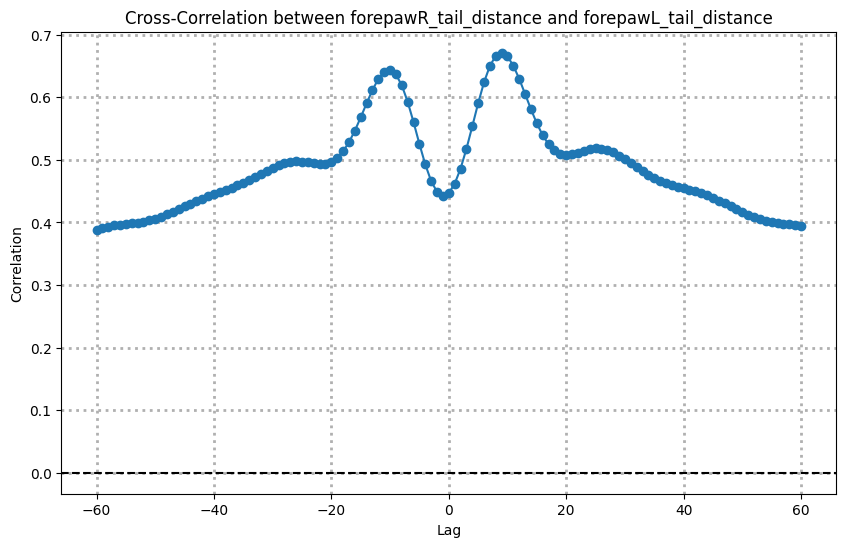

(array([-60, -59, -58, -57, -56, -55, -54, -53, -52, -51, -50, -49, -48,
        -47, -46, -45, -44, -43, -42, -41, -40, -39, -38, -37, -36, -35,
        -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22,
        -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10,  -9,
         -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,
          5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,
         18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,
         31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
         44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         57,  58,  59,  60]),
 array([0.38795707, 0.39074904, 0.39317103, 0.3951772 , 0.39673458,
        0.39789262, 0.39883511, 0.39984511, 0.40123296, 0.40322392,
        0.40588919, 0.40916615, 0.41292217, 0.41700457, 0.42128091,
        0.42563371, 0.42994493, 0.43409286, 0.43799202, 0.44163492,
        0.4451035 , 0.44853053, 0.4520465

In [64]:
compute_cross_correlation(data, "forepawR_tail_distance", "forepawL_tail_distance", 60)

## Create windows 

In [66]:

def robust_scale(s, eps=1e-12):
    med = s.median()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    denom = iqr if abs(iqr) > eps else s.std()
    denom = denom if abs(denom) > eps else 1.0
    return (s - med) / denom


def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


def winsorize(s, p=0.005):
    lo = s.quantile(p)
    hi = s.quantile(1 - p)
    return s.clip(lo, hi)


# ---------- CONFIG ----------

angle_cols = [
    "facing_angle",
    "rel_angle_target",
    "angle_head_body_axis",
    "angle_head_body_l",
    "angle_head_body_r",
    "ori_allBody",
    "ori_trunk",
    "ori_head",
]

log1p_nonneg = [
    "dist", "dist_head", "height", "height_scaled",
    "head_speed", "trunk_speed",
    "nose_tail_distance",
    "forepawL_tail_distance",
    "forepawR_tail_distance",
    "forepaw_target_distance",
    "dist_scaled", "dist_head_scaled",
]

signed_log = [
    "omega_theta_trunk",
    "head_acc",
    "rigidbody_acc",
    "tangential_vel",
]

# ---------- START CLEANING ----------

df = data.copy()

# Drop timestamp
if "timestamp" in df.columns:
    df = df.drop(columns="timestamp")

# Angles → sin/cos
for col in angle_cols:
    if col in df.columns:
        df[col + "_sin"] = np.sin(df[col])
        df[col + "_cos"] = np.cos(df[col])

df = df.drop(columns=[c for c in angle_cols if c in df.columns])

# Radial velocity → approach / retreat
if "radial_vel" in df.columns:
    rv = df["radial_vel"]
    df["radial_approach"] = np.clip(-rv, 0, None)
    df["radial_retreat"] = np.clip(rv, 0, None)
    df = df.drop(columns="radial_vel")

# Signed log on heavy-tailed signed vars
for col in signed_log:
    if col in df.columns:
        df[col] = signed_log1p(df[col])

# log1p on heavy-tailed NONNEGATIVE vars
for col in log1p_nonneg:
    if col in df.columns and (df[col] >= 0).all():
        df[col] = np.log1p(df[col])

# Winsorize numeric columns
for col in df.select_dtypes(include=np.number):
    df[col] = winsorize(df[col])

# Robust scale numeric columns
for col in df.select_dtypes(include=np.number):
    df[col] = robust_scale(df[col])

# Drop constant columns
df = df.loc[:, df.nunique() > 1]

data_clean = df

print("Cleaned shape:", data_clean.shape)
data_clean.head()


Cleaned shape: (74289, 39)


,dist_head,dist,dist_change,rel_bearing,height,height_scaled,head_acc,rigidbody_acc,speed_head_fwd,head_speed,...,facing_angle_sin,facing_angle_cos,angle_head_body_axis_sin,angle_head_body_axis_cos,angle_head_body_r_sin,angle_head_body_r_cos,ori_trunk_sin,ori_trunk_cos,radial_approach,radial_retreat
0,NaN,NaN,NaN,NaN,-0.639576,-0.551357,0.555949,0.885685,1.397709,0.727429,...,NaN,NaN,-0.564582,0.427238,-0.239401,0.664361,-0.384448,-0.584936,NaN,NaN
1,NaN,NaN,NaN,NaN,-0.650758,-0.559649,0.555949,0.885685,1.686054,0.654501,...,NaN,NaN,-0.477301,0.524848,-0.704149,-0.091661,-0.451284,-0.533825,NaN,NaN
2,NaN,NaN,NaN,NaN,-0.678179,-0.579801,0.555949,0.885685,1.794578,1.112396,...,NaN,NaN,-0.685128,0.164741,-0.547818,0.449308,-0.695060,-0.031018,NaN,NaN
3,NaN,NaN,NaN,NaN,-0.713426,-0.605329,0.555949,0.885685,1.773933,1.088251,...,NaN,NaN,-0.464225,-0.519844,-0.076780,0.701319,-0.337530,0.612795,NaN,NaN
4,NaN,NaN,NaN,NaN,-0.745567,-0.628245,0.573371,0.889664,1.722431,0.920425,...,NaN,NaN,0.370298,-0.596581,0.538707,-0.456630,0.356646,0.616895,NaN,NaN


<Axes: >

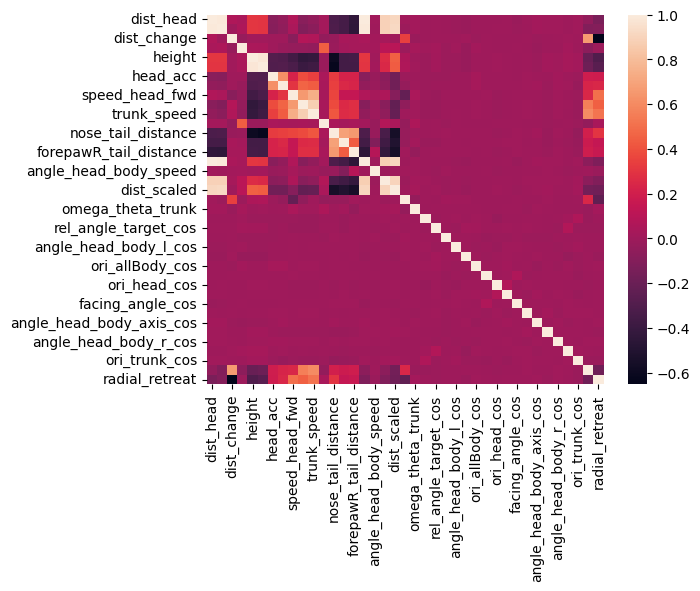

In [67]:
sns.heatmap(data_clean.corr())

Text(0, 0.5, 'cumulative variance')

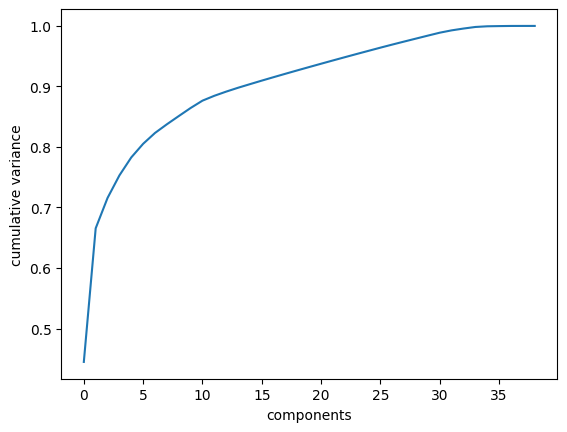

In [69]:
X = data_clean.dropna().values
pca = PCA()
Xp = pca.fit_transform(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("components")
plt.ylabel("cumulative variance")

In [70]:
fps = 60          
win_sec = 1.0
T = int(fps * win_sec)
stride = T // 2

X = data_clean.values
cols = data_clean.columns

windows = []

for start in range(0, len(X) - T + 1, stride):
    w = X[start:start+T]

    # mean
    mu = w.mean(axis=0)

    # std
    sd = w.std(axis=0)

    # linear slope per feature (captures trend)
    t = np.arange(T)
    slopes = np.polyfit(t, w, 1)[0]

    feat = np.concatenate([mu, sd, slopes])
    windows.append(feat)

windows = np.stack(windows)

# build dataframe
win_cols = (
    [c + "_mean" for c in cols] +
    [c + "_std" for c in cols] +
    [c + "_slope" for c in cols]
)

windows_df = pd.DataFrame(windows, columns=win_cols)

print("Windowed shape:", windows_df.shape)
windows_df.head()

Windowed shape: (2475, 117)


,dist_head_mean,dist_mean,dist_change_mean,rel_bearing_mean,height_mean,height_scaled_mean,head_acc_mean,rigidbody_acc_mean,speed_head_fwd_mean,head_speed_mean,...,facing_angle_sin_slope,facing_angle_cos_slope,angle_head_body_axis_sin_slope,angle_head_body_axis_cos_slope,angle_head_body_r_sin_slope,angle_head_body_r_cos_slope,ori_trunk_sin_slope,ori_trunk_cos_slope,radial_approach_slope,radial_retreat_slope
0,NaN,NaN,NaN,NaN,-0.419709,-0.373399,-0.095982,0.363181,0.789937,0.276540,...,NaN,NaN,0.000417,-0.002596,-0.003710,-0.011487,0.015882,-0.004439,NaN,NaN
1,NaN,NaN,NaN,NaN,-0.698902,-0.566632,-0.107063,0.309215,0.686825,0.184018,...,NaN,NaN,0.004917,-0.002210,0.013414,0.011091,-0.012334,0.010318,NaN,NaN
2,NaN,NaN,NaN,NaN,-0.953378,-0.761349,-0.276134,-0.231617,0.280596,-0.099502,...,NaN,NaN,0.005977,0.004992,0.009033,0.001938,0.019753,0.016574,NaN,NaN
3,NaN,NaN,NaN,NaN,-0.793292,-0.657349,-0.756129,-0.509448,-0.143468,-0.334976,...,NaN,NaN,-0.017884,0.011103,-0.018446,0.002868,-0.012479,0.008705,NaN,NaN
4,NaN,NaN,NaN,NaN,-0.754696,-0.632947,-0.620923,-0.239953,-0.177146,-0.300761,...,NaN,NaN,0.004873,0.000215,0.000994,-0.007069,-0.009438,0.002588,NaN,NaN


In [71]:
for c in windows_df.columns:
    windows_df[c] = robust_scale(windows_df[c])


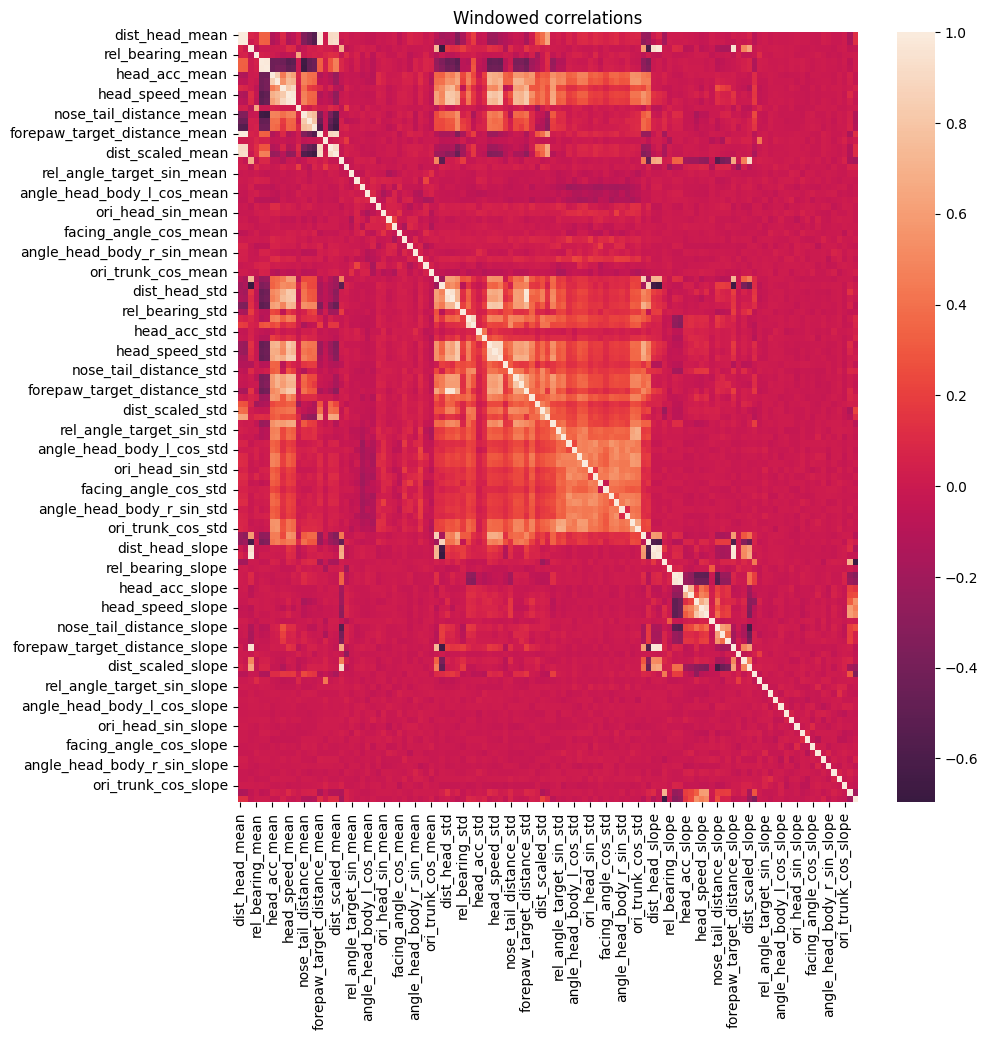

In [78]:
corr_win = windows_df.dropna().corr()


plt.figure(figsize=(10,10))
sns.heatmap(corr_win, cmap="rocket", center=0)
plt.title("Windowed correlations")
plt.show()


In [82]:
fps = 60        # CHANGE if needed
win_seconds = 1.0
T = int(fps * win_seconds)
stride = T // 2   # 50% overlap

# -------------------
# Build raw windows
# -------------------

X = data_clean.to_numpy(dtype=np.float32)   # (N, D)
feature_names = list(data_clean.columns)

N, D = X.shape
print("Frames:", N)
print("Features:", D)
print("Window length:", T)

windows = []
starts = []

for start in range(0, N - T + 1, stride):
    windows.append(X[start:start+T])
    starts.append(start)

X_windows = np.stack(windows)     # (W, T, D)
starts = np.array(starts)

print("Num windows:", X_windows.shape[0])
print("Tensor shape:", X_windows.shape)    # (W, T, D)

# -------------------
# Basic sanity checks
# -------------------

print("\nExample window (first 3 timesteps, first 5 features):")
print(X_windows[0, :3, :5])

print("\nFeature names:")
print(feature_names)

Frames: 74289
Features: 39
Window length: 60
Num windows: 2475
Tensor shape: (2475, 60, 39)

Example window (first 3 timesteps, first 5 features):
[[        nan         nan         nan         nan -0.63957584]
 [        nan         nan         nan         nan -0.65075797]
 [        nan         nan         nan         nan -0.6781794 ]]

Feature names:
['dist_head', 'dist', 'dist_change', 'rel_bearing', 'height', 'height_scaled', 'head_acc', 'rigidbody_acc', 'speed_head_fwd', 'head_speed', 'trunk_speed', 'tangential_vel', 'nose_tail_distance', 'forepawL_tail_distance', 'forepawR_tail_distance', 'forepaw_target_distance', 'angle_head_body_speed', 'dist_head_scaled', 'dist_scaled', 'dist_change_scaled', 'omega_theta_trunk', 'rel_angle_target_sin', 'rel_angle_target_cos', 'angle_head_body_l_sin', 'angle_head_body_l_cos', 'ori_allBody_sin', 'ori_allBody_cos', 'ori_head_sin', 'ori_head_cos', 'facing_angle_sin', 'facing_angle_cos', 'angle_head_body_axis_sin', 'angle_head_body_axis_cos', 'angle

In [83]:
keep = ["head_speed", "trunk_soeed", "dist_head", "notes_tail_distance", "radial_approach", "radial_retreat", "facing_angle_sin", "facing_angle_cos", "height_scaled"]
keep = [c for c in keep if c in data_clean.columns]  # only keep what exists
data_small = data_clean[keep].copy()

print("Using features:", data_small.columns.tolist())
print("Shape:", data_small.shape)

Using features: ['head_speed', 'dist_head', 'radial_approach', 'radial_retreat', 'facing_angle_sin', 'facing_angle_cos', 'height_scaled']
Shape: (74289, 7)


In [84]:
fps = 60
win_seconds = 1.0
T = int(fps * win_seconds)
stride = T // 2

X = data_small.to_numpy(dtype=np.float32)  # (N, D)
N, D = X.shape

windows = []
for start in range(0, N - T + 1, stride):
    windows.append(X[start:start+T])

X_windows = np.stack(windows)  # (W, T, D)
print("X_windows:", X_windows.shape)

X_windows: (2475, 60, 7)
